<div class="alert alert-info" markdown="1">

#### Homework 3, Problem 7 Supplemental Notebook

# Lines, Orthogonality, and Projections in $\mathbb{R}^2$

### Math 124: Vectors, Matrices, and Applications, Fall 2026

<small><a style="text-decoration: none" href="https://math124.org">math124.org</a></small>

</div>

### Instructions

Most homeworks and some labs will have a Jupyter Notebook, like this one, containing Python code that supplements our understanding of the relevant mathematical ideas of the week.

---

Open this notebook in Google Colab. Instructions on how to use Google Colab are at [math124.org/running-code](https://math124.org/running-code).

**Most importantly, make sure to click "Copy to Drive" and rename the notebook before proceeding!**

---

Together, the tasks in this notebook constitute your score for Homework 3, Problem 7, worth **15 points**. You won't need to submit this notebook anywhere. Instead, at the bottom, we'll tell you what to include in your PDF submission for Homework 3 that you upload to Pensive.

Work from top to bottom. Replace `...` only in the task cells, then run those cells. The longer plotting and data cells are supplied for you: run them without editing them. If you change a function, run its cell again and rerun the cells below it so they use your new version.


## Runway Wind Analysis ✈️

---

In Homework 1, you wrote functions that transformed the colors in an image. In Homework 2, you wrote a function that compared the directions of two vectors, then used it to explore presidential speeches.

**Goal: Describe how much of a wind blows along a runway and how much blows across it.** As we see in [Chapter 2.3](https://notes.math124.org/ch02/02-03/#decomposing-a-vector-into-perpendicular-components), splitting a vector into two perpendicular parts is called **orthogonal decomposition**. You'll implement a small vector calculation, then use it to explore real wind observations from Ann Arbor Municipal Airport, just south of campus (near Costco).

Imagine an aircraft moving in a particular direction along a runway. 
- A **headwind** blows **against** that direction, 
- a **tailwind** blows in that direction, and 
- a **crosswind** blows **across** it. 

One wind can have both an along-runway component and a cross-runway component! The following diagram describes the relationship between these three types of winds.

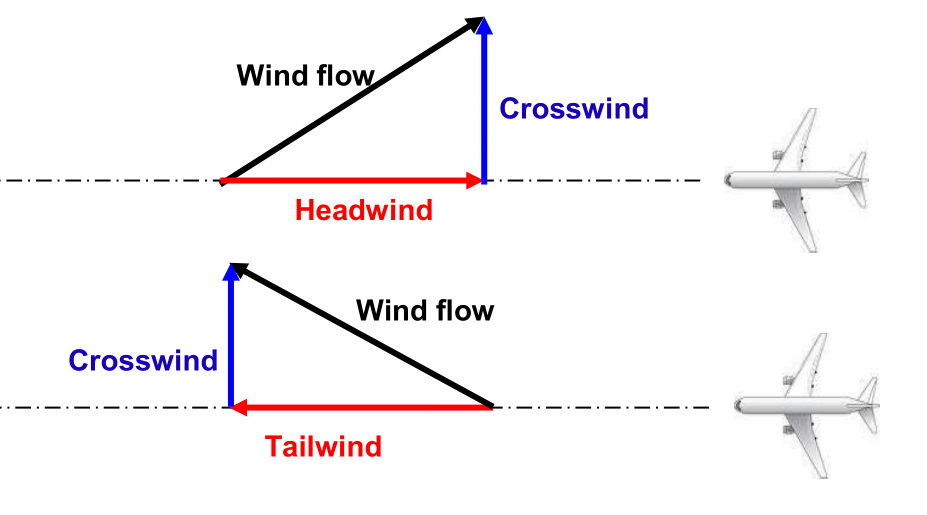

The same wind can blow along one runway and across another. We will describe one wind using two sets of directions: 
1. The amount it travels east (one number) and north (one number), 
1. The amount it travels along (one number) and across (one number) the runway.

**Importantly, the wind itself is the same – it's just that the directions we use to describe it change.** This is the purpose of choosing a different basis. We'll first represent a wind as a vector, then choose directions along and across a runway, then use dot products to find the "two numbers" in the second bullet point above. Finally, we'll repeat your calculation on real observations.

Ann Arbor's two physical runways can each be used in two directions, labeled **06/24** and **12/30**, according to [airnav.com](https://www.airnav.com/airport/ARB). Those four directions correspond (approximately) to the angles $60^\circ$, $240^\circ$, $120^\circ$, and $300^\circ$, all relative to true north.

**Open Google/Apple maps, find the Ann Arbor airport, and look at the orientation of the runways you see!** You will likely only see one, which seems to move roughly from the bottom-left to the top-right – this is the **06/24** ($60^\circ$ and $240^\circ$). The 12/30 runway is a secondary airport made of grass, so it doesn't appear on mapping software.


## Wind and runways as vectors

---

### Wind vectors

We use **east-north coordinates**: the first coordinate measures motion east, and the second measures motion north. Negative coordinates indicate west and south, respectively.

Weather reports describe the direction wind comes **from**. Our vector points in the direction the air moves **toward**. For example, a 10-knot wind **from the west** moves east, so its vector is

$$\vec w=\begin{bmatrix}10\\0\end{bmatrix}.$$

A knot is a unit of speed equal to one nautical mile per hour. Every wind coordinate and component in this notebook is measured in knots.

For example, $\begin{bmatrix}3\\4\end{bmatrix}$ describes air moving east at 3 knots and north at 4 knots at the same time. Its total speed is the vector's length, $\sqrt{3^2+4^2}=5$ knots. As we saw in Homework 2's notebook, we write this column vector as `np.array([3, 4])`; NumPy displays its entries in a row, but we use it to represent the same vector.

First, import NumPy by running the cell below.

In [ ]:
import numpy as np

<div class="alert alert-warning" markdown="1">

### Task 1: Define Wind Vectors (3 pts)

</div>

Define the following two wind vectors as NumPy arrays, using east-north coordinate order:

1. `w_from_north`: an 8-knot wind **from the north**.
2. `w_from_north_east`: an 8-knot wind **from the northeast**, exactly halfway between north and east.

Think about where the air moves before deciding the signs. For the northeast wind, the two coordinates have equal magnitude, and the vector's **total length** must be 8. Use the length formula to determine each coordinate; you can use `np.sqrt` to take a square root. Keep exact expressions rather than rounding.

In [ ]:
w_from_north = np.array(...)
w_from_north

In [ ]:
w_from_north_east = np.array(...)
w_from_north_east

Run the cell below to visualize your two vectors; this will help you decide if you did the calculations correctly.

In [ ]:
#@title Set up the plot style { display-mode: "form" }
import plotly.graph_objects as go

PLOT_FONT = 'Palatino, Georgia, serif'
PLOT_BLUE = '#2467A0'
PLOT_GOLD = '#B8860B'
PLOT_INK = '#202020'
PLOT_GRAY = '#999999'
PLOT_CONFIG = {'displaylogo': False, 'responsive': True}

def style_wind_plot(figure):
    figure.update_layout(
        template='plotly_white', width=800,
        font=dict(family=PLOT_FONT, size=14, color=PLOT_INK),
        title=dict(x=0.5, xanchor='center', font=dict(family=PLOT_FONT, size=20)),
        paper_bgcolor='white', plot_bgcolor='white',
        colorway=[PLOT_BLUE, PLOT_GOLD, PLOT_INK, PLOT_GRAY],
        hoverlabel=dict(bgcolor='white', font=dict(family=PLOT_FONT, size=14)),
        annotationdefaults=dict(font=dict(family=PLOT_FONT, size=14)),
        legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.18,
                    font=dict(family=PLOT_FONT, size=14), bgcolor='rgba(0,0,0,0)')
    )
    figure.update_xaxes(
        title_font=dict(family=PLOT_FONT, size=16),
        tickfont=dict(family=PLOT_FONT, size=13),
        showgrid=True, gridcolor='#E8E8E8', gridwidth=1,
        zeroline=True, zerolinecolor=PLOT_GRAY, zerolinewidth=1
    )
    figure.update_yaxes(
        title_font=dict(family=PLOT_FONT, size=16),
        tickfont=dict(family=PLOT_FONT, size=13),
        showgrid=True, gridcolor='#E8E8E8', gridwidth=1,
        zeroline=True, zerolinecolor=PLOT_GRAY, zerolinewidth=1
    )
    figure.update_traces(textfont=dict(family=PLOT_FONT, size=14), selector=dict(type='scatter'))
    figure.update_annotations(font_family=PLOT_FONT)
    for menu in figure.layout.updatemenus:
        menu.font = dict(family=PLOT_FONT, size=14, color=PLOT_INK)
        menu.bgcolor = 'white'
        menu.bordercolor = '#CCCCCC'
    return figure


#@title Plot your two wind vectors { display-mode: "form" }
import plotly.graph_objects as go

# Plot the arrays you defined above, without changing their values.
wind_vectors = [
    ('w_from_north', w_from_north, PLOT_BLUE),
    ('w_from_north_east', w_from_north_east, PLOT_GOLD),
]
wind_plot = go.Figure()
wind_plot_extent = 8.0
for name, values, color in wind_vectors:
    try:
        vector = np.asarray(values, dtype=float)
    except (TypeError, ValueError):
        raise ValueError(f'Complete {name} with two numbers and rerun its cell first.') from None
    if vector.shape != (2,) or not np.isfinite(vector).all():
        raise ValueError(f'{name} must contain exactly two finite numbers.')
    east, north = vector
    speed = np.linalg.norm(vector)
    wind_plot_extent = max(wind_plot_extent, float(np.max(np.abs(vector))))
    wind_plot.add_trace(go.Scatter(
        x=[0, east], y=[0, north], mode='lines+markers',
        name=name, line=dict(color=color, width=3),
        marker=dict(color=color, size=[0, 7]),
        customdata=[[speed], [speed]],
        hovertemplate=(name + '<br>East: %{x:.3f} knots'
                       '<br>North: %{y:.3f} knots'
                       '<br>Length: %{customdata[0]:.3f} knots<extra></extra>')
    ))
    wind_plot.add_annotation(
        x=east, y=north, xref='x', yref='y',
        text=name, showarrow=False,
        xshift=14, yshift=-14 if name == 'w_from_north' else 18,
        xanchor='left', yanchor='middle',
        font=dict(family=PLOT_FONT, size=14, color=color)
    )
    if speed > 0:
        wind_plot.add_annotation(
            x=east, y=north, ax=0, ay=0,
            xref='x', yref='y', axref='x', ayref='y',
            text='', showarrow=True, arrowhead=3,
            arrowsize=1.3, arrowwidth=3, arrowcolor=color
        )
    print(f'{name}: east = {east:.3f}, north = {north:.3f}; length = {speed:.3f} knots')

wind_plot_extent *= 1.5
wind_plot.update_layout(
    title='Your wind vectors',
    template='plotly_white', width=700, height=650,
    margin=dict(l=75, r=75, t=70, b=100),
    xaxis=dict(title='Eastward wind velocity (knots)',
               range=[-wind_plot_extent, wind_plot_extent],
               zeroline=True, zerolinecolor='gray', constrain='domain'),
    yaxis=dict(title='Northward wind velocity (knots)',
               range=[-wind_plot_extent, wind_plot_extent],
               zeroline=True, zerolinecolor='gray',
               scaleanchor='x', scaleratio=1, constrain='domain'),
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.15)
)
print('Check: do the arrows point away from where each wind comes from, and do both have length 8?')
print('If you change an array, rerun its cell and this plotting cell.')
style_wind_plot(wind_plot).show(config=PLOT_CONFIG)


**🚨 For Task 1, in your PDF, include a screenshot of the plot above. 🚨**

### Direction vectors for runways

To split a wind into an along-runway part and a cross-runway part, we need a vector that describes the direction of the runway and the direction perpendicular to the runway. Throughout this notebook, we will use the following definitions: 
- Let $\vec u$ point forward along the runway.
- Let $\vec v$ point to the **right** of an aircraft facing that direction. 

We choose both to be unit vectors (i.e. have length $1$), so they specify directions without introducing an extra scale factor. To be clear, $\vec u$ and $\vec v$ are not wind vectors – they describe the position of a runway.

A **bearing** $\phi$ is an angle measured **clockwise from north**: $0^\circ$ points north, $90^\circ$ east, $180^\circ$ south, and $270^\circ$ west. A full turn, $360^\circ$, points north again.

Because we measure from the north axis, the north coordinate is $\cos\phi$ and the east coordinate is $\sin\phi$. (This is different from how we typically measure angles, relative to the $x$-axis, or east.) In our east-north coordinate order,

$$\vec u=\begin{bmatrix}\sin\phi\\\cos\phi\end{bmatrix}.$$

Turning a vector $\begin{bmatrix}x\\y\end{bmatrix}$ $90^\circ$ clockwise gives $\begin{bmatrix}y\\-x\end{bmatrix}$. That gives the direction to the aircraft's right:

$$\vec v=\begin{bmatrix}\cos\phi\\-\sin\phi\end{bmatrix}.$$

For example, when $\phi=0^\circ$, $\vec u=\begin{bmatrix}0\\1\end{bmatrix}$ points north and $\vec v=\begin{bmatrix}1\\0\end{bmatrix}$ points east. East is to your right when you face north.

The vectors form an **orthonormal basis** of $\mathbb{R}^2$: they are perpendicular unit vectors, so any vector in $\mathbb{R}^2$ can be written uniquely as a linear combination of them. They act like a pair of coordinate axes aligned with the runway.

Run the cell below to define `runway_basis`. It takes an angle in degrees and returns two arrays, first `u`, then `v`. The line `u240, v240 = runway_basis(240)` stores both arrays for Runway 24. The `240` in these names is its bearing in degrees. NumPy uses radians for trigonometry, so `np.deg2rad` converts degrees to radians for us.

In [ ]:
def runway_basis(bearing_degrees):
    phi = np.deg2rad(bearing_degrees)
    u = np.array([np.sin(phi), np.cos(phi)])
    v = np.array([np.cos(phi), -np.sin(phi)])
    return u, v

u240, v240 = runway_basis(240)

In [ ]:
u240


In [ ]:
v240


Run the supplied cell below, then drag the slider. The thick gray line shows the runway's orientation; the blue vector $\vec u$ points forward and the gold vector $\vec v$ points to the aircraft's right. This is a diagram of directions, not a map drawn to scale.

**Before Task 2:** Try $0^\circ$ and $90^\circ$. Check that the arrows point where you would expect if you faced north, then east. Then try $240^\circ$. Notice that both arrows turn, but their lengths and the angle between them stay the same. The formulas above the plot show their east-north coordinates, rounded to three decimals.

The slider does not change `u240` or `v240`; those arrays stay fixed at $240^\circ$ for the tasks below.


In [ ]:
#@title Explore runway directions { display-mode: "form" }
import plotly.graph_objects as go

def runway_view(bearing_degrees):
    u, v = runway_basis(bearing_degrees)
    angle = rf'{bearing_degrees}^\circ'

    # Avoid displaying negative zero at cardinal bearings.
    def decimal(value):
        return f'{0.0 if abs(value) < 0.0005 else value:.3f}'

    formula = (
        rf'\vec u=\begin{{bmatrix}}\sin({angle})\\\cos({angle})\end{{bmatrix}}'
        rf'=\begin{{bmatrix}}{decimal(u[0])}\\{decimal(u[1])}\end{{bmatrix}}'
        r'\qquad '
        rf'\vec v=\begin{{bmatrix}}\cos({angle})\\-\sin({angle})\end{{bmatrix}}'
        rf'=\begin{{bmatrix}}{decimal(v[0])}\\{decimal(v[1])}\end{{bmatrix}}'
    )
    fig = go.Figure()
    runway_x = [-1.18*u[0], 1.18*u[0]]
    runway_y = [-1.18*u[1], 1.18*u[1]]
    fig.add_trace(go.Scatter(
        x=runway_x, y=runway_y, mode='lines',
        line=dict(color='rgba(128,128,128,0.25)', width=30),
        hoverinfo='skip', showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=runway_x, y=runway_y, mode='lines',
        line=dict(color='white', width=2, dash='dash'),
        hoverinfo='skip', showlegend=False
    ))
    for vector, label, color in [(u, 'u', PLOT_BLUE), (v, 'v', PLOT_GOLD)]:
        fig.add_annotation(
            x=vector[0], y=vector[1], ax=0, ay=0,
            xref='x', yref='y', axref='x', ayref='y',
            text='', showarrow=True, arrowhead=3, arrowsize=1.4,
            arrowwidth=3, arrowcolor=color
        )
        fig.add_annotation(
            x=1.12*vector[0], y=1.12*vector[1],
            text=f'<b>{label}</b>', showarrow=False,
            font=dict(color=color, size=16)
        )
        fig.add_trace(go.Scatter(
            x=[vector[0]], y=[vector[1]], mode='markers',
            marker=dict(size=8, color=color), name=label,
            hovertemplate=f'{label} = (%{{x:.3f}}, %{{y:.3f}})<extra></extra>',
            showlegend=False
        ))
    fig.add_trace(go.Scatter(
        x=[0], y=[0], mode='markers', marker=dict(color='black', size=6),
        hoverinfo='skip', showlegend=False
    ))
    fig.update_layout(
        template='plotly_white', height=720,
        title=dict(text=f'Runway bearing φ = {bearing_degrees}°'
                        '<br><sup>Clockwise from north</sup>', x=0.5),
        margin=dict(l=65, r=35, t=175, b=130),
        xaxis=dict(title='East', range=[-1.4, 1.4], dtick=0.5,
                   zeroline=True, zerolinecolor='lightgray', constrain='domain'),
        yaxis=dict(title='North', range=[-1.4, 1.4], dtick=0.5,
                   zeroline=True, zerolinecolor='lightgray',
                   scaleanchor='x', scaleratio=1, constrain='domain')
    )
    fig.add_annotation(
        x=0.5, y=1.15, xref='paper', yref='paper',
        text='$' + formula + '$', showarrow=False,
        xanchor='center', yanchor='bottom', font=dict(size=17)
    )
    return fig


# Every slider state is embedded in this Plotly figure; no widget callbacks.
runway_figure = runway_view(240)
phi_steps = []
for bearing in range(361):
    view = runway_view(bearing)
    phi_steps.append(dict(
        label=str(bearing), method='update',
        args=[dict(x=[list(trace.x) for trace in view.data],
                   y=[list(trace.y) for trace in view.data]),
              dict(annotations=[a.to_plotly_json() for a in view.layout.annotations],
                   title=dict(text=view.layout.title.text))]
    ))
runway_figure.update_layout(sliders=[dict(
    active=240, x=0, len=1, y=-0.08, pad=dict(t=20),
    currentvalue=dict(prefix='φ = ', suffix='°',
                      font=dict(family=PLOT_FONT, size=16)),
    font=dict(family=PLOT_FONT, size=12), steps=phi_steps
)])
style_wind_plot(runway_figure).show(config=PLOT_CONFIG)


<div class="alert alert-warning" markdown="1">

### Task 2: Verify the Runway Basis (0 pts; practice)

</div>


Complete the three calculations below to verify that `u240` and `v240` form an orthonormal basis.

Recall: `np.dot(u, v)` computes a dot product, and `np.linalg.norm(u)` computes a vector's length. `len(u)` counts entries instead.

In [ ]:
# The lengths should be approximately 1, and the dot product approximately 0.
length_u = np.linalg.norm(...)
length_v = ...
dot_uv = ...
print('Length of u240:', length_u)
print('Length of v240:', length_v)
print('Dot product:', dot_uv)

**🚨 For Task 2, in your PDF, there is nothing to submit. 🚨**

Computers store most real numbers approximately. A result such as `-2e-17` means $-2\times10^{-17}$, which is extremely close to zero. Small discrepancies of this size are expected here.

## Decomposing wind vectors

---

Now we have two direction vectors, $\vec u$ and $\vec v$, which together describe the direction of a runway. We want to find **how much of each** is needed to make a given wind vector:

$$\vec w=a\vec u+b\vec v.$$

Here, $a$ and $b$ are scalars. The vectors $a\vec u$ and $b\vec v$ are the along-runway and cross-runway parts of the wind.

### Example: North-facing runway

As an example, suppose an aircraft is on a runway facing directly north, so $\vec u=\begin{bmatrix}0\\1\end{bmatrix}$ and $\vec v=\begin{bmatrix}1\\0\end{bmatrix}$. For $\vec w=\begin{bmatrix}3\\4\end{bmatrix}$,

the northward part is 4 knots and the eastward part is 3 knots, so $a=4$ and $b=3$. Here we can read the components directly from the coordinates because the runway points north.

We recover the same wind by adding its two perpendicular parts:

$$a\vec u+b\vec v
=4\begin{bmatrix}0\\1\end{bmatrix}+3\begin{bmatrix}1\\0\end{bmatrix}
=\begin{bmatrix}0\\4\end{bmatrix}+\begin{bmatrix}3\\0\end{bmatrix}
=\begin{bmatrix}3\\4\end{bmatrix} = \vec w.$$

This wind moves forward at 4 knots and to the aircraft's right at 3 knots. Its total speed is 5 knots, not $4+3=7$: we add the **vectors**, not their lengths.

### For any runway

For a tilted runway, we cannot simply read $a$ and $b$ from the east-north coordinates. Dot products let us find them in the new directions, as we saw in Lab 3 and [Chapter 2.2](https://notes.math124.org/ch02/02-02/). To write $\vec w$ as $a \vec u + b \vec v$, because $\vec u$ and $\vec v$ form an orthogonal basis, 

$$a = \vec w \cdot \vec u, \qquad b = \vec w \cdot \vec v.$$

We call $a$ a **signed scalar component**: it is a number telling us how much wind acts in the $\vec u$ direction. The **vector projection** onto the runway's direction is $a\vec u$. Because $\vec u$ has length 1, that projection has length $|a|$. The same distinction applies to $b$ and $b\vec v$.

Since $\vec u$ points in the aircraft's forward direction:

- $a<0$: air moves against that direction, so there is a **headwind** of $|a|$ knots.
- $a>0$: air moves in that direction, so there is a **tailwind** of $a$ knots.
- $a=0$: there is no along-runway part.

Since $\vec v$ points to the aircraft's right, $b>0$ means air moves to its right and $b<0$ means air moves to its left. The **crosswind magnitude** is $|b|$ knots. For example, $b=-3$ means a crosswind of magnitude 3 knots moving to the left, not a negative speed. If $b=0$, there is no crosswind.

These signs depend on which way the aircraft faces. Note that neither $a$ nor $b$ is generally an east or north coordinate; they describe the wind relative to the runway!

<div class="alert alert-warning" markdown="1">

### Task 3: Implement a Signed Component (0 pts; practice)

</div>


Complete the implementation of the function `signed_component(w, u)`. It takes a wind vector `w` and a **unit** direction vector `u` (in that order) and returns the signed scalar component of `w` in that direction. You may assume both inputs are NumPy arrays with two entries and that `u` has length 1.

Example behavior is given below.

```python
>>> signed_component(np.array([3, 4]), np.array([1, 0]))
3

>>> signed_component(np.array([3, 4]), np.array([0, -1]))
-4

>>> signed_component(np.array([3, 4]), np.array([0.6, 0.8]))
5.0
```

Your function will let the supplied code repeat this same dot product for many winds and directions. Return a **number**, not a projection vector, and keep its sign. Do not round inside the function.

To understand the examples: the first measures the eastward part; the second measures the southward part, which is negative because this wind moves north; in the third, the unit direction points the same way as the wind, so the component equals the wind's length, 5.

In [ ]:
def signed_component(w, u):
    ...

# Compare with the examples above.
print(signed_component(np.array([3, 4]), np.array([1, 0])))
print(signed_component(np.array([3, 4]), np.array([0, -1])))
print(signed_component(np.array([3, 4]), np.array([0.6, 0.8])))

**🚨 For Task 3, in your PDF, there is nothing to submit. 🚨**

<div class="alert alert-warning" markdown="1">

### Task 4: Reconstruct One Wind Vector (4 pts)

</div>


We have seen reconstruction for a north-facing runway. Now use the same steps for a tilted one: **Runway 24**, with bearing $240^\circ$. For wind, let's still use a 10-knot wind from the west, `w = np.array([10, 0])`.

Before calculating, look at the slider at $240^\circ$ from earlier: the aircraft faces southwest while this wind moves east. Predict whether the along-runway part will be a headwind or a tailwind. You will check your prediction with the sign of `a`.

Complete the cell below:

1. Use `signed_component` with `w` and `u240` to find `a`.
2. Use the same function with `w` and `v240` to find `b`.
3. Translate $a\vec u+b\vec v$ into NumPy scalar multiplication and vector addition to reconstruct `w`. Recall that `*` multiplies an array by a scalar and `+` adds arrays entry by entry.

The reconstructed vector should be approximately `[10, 0]`. This checks that the two runway-relative parts add up to the original wind. Keep full precision in your calculation; tiny differences from zero are expected.

In [ ]:
w = np.array([10, 0])
a = ...
b = ...
reconstructed_w = ...

print('Along-runway scalar component:', a)
print('Cross-runway scalar component:', b)
print('Reconstructed wind:', reconstructed_w)

**🚨 For Task 4, in your PDF, include: 🚨**

- **A screenshot of the code above.**
- **State what the sign of $a$ is, and use this to identify whether the wind `w = np.array([10, 0])` is a headwind or tailwind for Runway 24, and state the crosswind magnitude $|b|$.**

## Real Data

---

Tasks 3 and 4 give us a calculation we can repeat: choose a runway basis, take two dot products, and interpret the signs. We can now ask how the along-runway and cross-runway parts vary across many winds.

We'll use your function on observations from **Ann Arbor Municipal Airport (KARB), September 1-7, 2025, in UTC**. UTC is four hours ahead of Ann Arbor local time during this interval.

The observations come from the [Iowa Environmental Mesonet's airport weather archive](https://mesonet.agron.iastate.edu/request/download.phtml). Each row describes one weather report, including its time, wind direction, and sustained wind speed. Reports are not evenly spaced, so a fraction of reports is not necessarily the same as a fraction of time. Our conclusions describe this week of reports; they do not establish a year-round pattern.

**Once you have successfully completed Tasks 3 and 4, run the provided setup cell below. You do not need to write, change, or understand its code.** It loads a fixed copy of the data, converts winds to east–north vectors, and uses your `signed_component` function for the runway calculations. Calm winds become zero vectors. Reports with missing speed or an unusable direction for a nonzero wind are excluded.

The data are included in the notebook so that everyone uses the same observations, even without a connection to the weather archive.

In [ ]:
#@title Load the wind observations and compute their components { display-mode: "form" }
import csv
import io
from pathlib import Path
from datetime import datetime

# Frozen IEM response, downloaded September 14, 2026.
# Source query and filtering details are recorded in data/README.md.
WIND_CSV = 'station,valid,drct,sknt\nARB,2025-09-01 00:53,0.00,0.00\nARB,2025-09-01 01:53,0.00,0.00\nARB,2025-09-01 02:53,0.00,0.00\nARB,2025-09-01 03:33,0.00,0.00\nARB,2025-09-01 03:35,0.00,0.00\nARB,2025-09-01 03:46,0.00,0.00\nARB,2025-09-01 03:53,0.00,0.00\nARB,2025-09-01 04:01,0.00,0.00\nARB,2025-09-01 04:26,0.00,0.00\nARB,2025-09-01 04:53,0.00,0.00\nARB,2025-09-01 05:35,0.00,0.00\nARB,2025-09-01 05:38,0.00,0.00\nARB,2025-09-01 05:45,0.00,0.00\nARB,2025-09-01 05:47,0.00,0.00\nARB,2025-09-01 05:50,0.00,0.00\nARB,2025-09-01 05:53,0.00,0.00\nARB,2025-09-01 06:04,0.00,0.00\nARB,2025-09-01 06:09,0.00,0.00\nARB,2025-09-01 06:11,0.00,0.00\nARB,2025-09-01 06:18,0.00,0.00\nARB,2025-09-01 06:27,0.00,0.00\nARB,2025-09-01 06:29,0.00,0.00\nARB,2025-09-01 06:38,0.00,0.00\nARB,2025-09-01 06:43,0.00,0.00\nARB,2025-09-01 06:45,0.00,0.00\nARB,2025-09-01 06:53,0.00,0.00\nARB,2025-09-01 06:56,0.00,0.00\nARB,2025-09-01 06:59,0.00,0.00\nARB,2025-09-01 07:11,0.00,0.00\nARB,2025-09-01 07:13,0.00,0.00\nARB,2025-09-01 07:25,0.00,0.00\nARB,2025-09-01 07:27,0.00,0.00\nARB,2025-09-01 07:37,0.00,0.00\nARB,2025-09-01 07:40,0.00,0.00\nARB,2025-09-01 07:49,0.00,0.00\nARB,2025-09-01 07:53,0.00,0.00\nARB,2025-09-01 07:56,0.00,0.00\nARB,2025-09-01 08:05,0.00,0.00\nARB,2025-09-01 08:18,0.00,0.00\nARB,2025-09-01 08:23,0.00,0.00\nARB,2025-09-01 08:53,0.00,0.00\nARB,2025-09-01 08:59,0.00,0.00\nARB,2025-09-01 09:01,0.00,0.00\nARB,2025-09-01 09:08,0.00,0.00\nARB,2025-09-01 09:24,0.00,0.00\nARB,2025-09-01 09:27,0.00,0.00\nARB,2025-09-01 09:48,0.00,0.00\nARB,2025-09-01 09:50,0.00,0.00\nARB,2025-09-01 09:53,0.00,0.00\nARB,2025-09-01 09:55,0.00,0.00\nARB,2025-09-01 10:05,0.00,0.00\nARB,2025-09-01 10:23,0.00,0.00\nARB,2025-09-01 10:30,0.00,0.00\nARB,2025-09-01 10:37,0.00,0.00\nARB,2025-09-01 10:44,0.00,0.00\nARB,2025-09-01 10:47,0.00,0.00\nARB,2025-09-01 10:53,0.00,0.00\nARB,2025-09-01 11:05,0.00,0.00\nARB,2025-09-01 11:13,0.00,0.00\nARB,2025-09-01 11:18,0.00,0.00\nARB,2025-09-01 11:26,0.00,0.00\nARB,2025-09-01 11:34,0.00,0.00\nARB,2025-09-01 11:39,0.00,0.00\nARB,2025-09-01 11:46,0.00,0.00\nARB,2025-09-01 11:53,0.00,0.00\nARB,2025-09-01 12:53,40.00,5.00\nARB,2025-09-01 13:53,60.00,4.00\nARB,2025-09-01 14:53,M,5.00\nARB,2025-09-01 15:53,M,M\nARB,2025-09-01 16:53,100.00,4.00\nARB,2025-09-01 17:53,130.00,5.00\nARB,2025-09-01 18:53,M,5.00\nARB,2025-09-01 19:53,80.00,7.00\nARB,2025-09-01 20:53,100.00,8.00\nARB,2025-09-01 21:53,M,3.00\nARB,2025-09-01 22:53,120.00,7.00\nARB,2025-09-01 23:53,130.00,3.00\nARB,2025-09-02 00:53,0.00,0.00\nARB,2025-09-02 01:53,0.00,0.00\nARB,2025-09-02 02:53,0.00,0.00\nARB,2025-09-02 03:53,0.00,0.00\nARB,2025-09-02 04:53,0.00,0.00\nARB,2025-09-02 05:36,0.00,0.00\nARB,2025-09-02 05:44,0.00,0.00\nARB,2025-09-02 05:53,0.00,0.00\nARB,2025-09-02 05:55,0.00,0.00\nARB,2025-09-02 06:02,0.00,0.00\nARB,2025-09-02 06:08,0.00,0.00\nARB,2025-09-02 06:23,0.00,0.00\nARB,2025-09-02 06:26,0.00,0.00\nARB,2025-09-02 06:40,0.00,0.00\nARB,2025-09-02 06:48,0.00,0.00\nARB,2025-09-02 06:53,0.00,0.00\nARB,2025-09-02 07:19,0.00,0.00\nARB,2025-09-02 07:27,0.00,0.00\nARB,2025-09-02 07:30,0.00,0.00\nARB,2025-09-02 07:37,0.00,0.00\nARB,2025-09-02 07:53,0.00,0.00\nARB,2025-09-02 08:33,0.00,0.00\nARB,2025-09-02 08:35,0.00,0.00\nARB,2025-09-02 08:46,0.00,0.00\nARB,2025-09-02 08:53,0.00,0.00\nARB,2025-09-02 09:00,0.00,0.00\nARB,2025-09-02 09:10,0.00,0.00\nARB,2025-09-02 09:14,0.00,0.00\nARB,2025-09-02 09:35,0.00,0.00\nARB,2025-09-02 09:42,0.00,0.00\nARB,2025-09-02 09:50,0.00,0.00\nARB,2025-09-02 09:53,0.00,0.00\nARB,2025-09-02 10:06,0.00,0.00\nARB,2025-09-02 10:13,0.00,0.00\nARB,2025-09-02 10:53,60.00,3.00\nARB,2025-09-02 11:30,0.00,0.00\nARB,2025-09-02 11:39,0.00,0.00\nARB,2025-09-02 11:53,0.00,0.00\nARB,2025-09-02 12:53,60.00,4.00\nARB,2025-09-02 13:53,M,3.00\nARB,2025-09-02 14:53,0.00,0.00\nARB,2025-09-02 15:53,100.00,5.00\nARB,2025-09-02 16:53,M,3.00\nARB,2025-09-02 17:53,M,3.00\nARB,2025-09-02 18:53,220.00,6.00\nARB,2025-09-02 19:53,140.00,3.00\nARB,2025-09-02 20:53,140.00,7.00\nARB,2025-09-02 21:53,110.00,4.00\nARB,2025-09-02 22:53,190.00,4.00\nARB,2025-09-02 23:53,130.00,4.00\nARB,2025-09-03 00:53,0.00,0.00\nARB,2025-09-03 01:53,0.00,0.00\nARB,2025-09-03 02:53,0.00,0.00\nARB,2025-09-03 03:53,0.00,0.00\nARB,2025-09-03 04:53,0.00,0.00\nARB,2025-09-03 05:39,0.00,0.00\nARB,2025-09-03 05:51,230.00,3.00\nARB,2025-09-03 05:53,230.00,3.00\nARB,2025-09-03 06:00,220.00,3.00\nARB,2025-09-03 06:06,0.00,0.00\nARB,2025-09-03 06:13,0.00,0.00\nARB,2025-09-03 06:21,0.00,0.00\nARB,2025-09-03 06:23,0.00,0.00\nARB,2025-09-03 06:35,0.00,0.00\nARB,2025-09-03 06:43,0.00,0.00\nARB,2025-09-03 06:53,0.00,0.00\nARB,2025-09-03 07:53,0.00,0.00\nARB,2025-09-03 08:06,0.00,0.00\nARB,2025-09-03 08:15,0.00,0.00\nARB,2025-09-03 08:23,0.00,0.00\nARB,2025-09-03 08:28,0.00,0.00\nARB,2025-09-03 08:38,0.00,0.00\nARB,2025-09-03 08:50,0.00,0.00\nARB,2025-09-03 08:53,0.00,0.00\nARB,2025-09-03 08:58,0.00,0.00\nARB,2025-09-03 09:09,0.00,0.00\nARB,2025-09-03 09:17,0.00,0.00\nARB,2025-09-03 09:31,0.00,0.00\nARB,2025-09-03 09:38,0.00,0.00\nARB,2025-09-03 09:53,0.00,0.00\nARB,2025-09-03 09:59,0.00,0.00\nARB,2025-09-03 10:06,0.00,0.00\nARB,2025-09-03 10:10,0.00,0.00\nARB,2025-09-03 10:17,0.00,0.00\nARB,2025-09-03 10:38,0.00,0.00\nARB,2025-09-03 10:45,0.00,0.00\nARB,2025-09-03 10:53,260.00,3.00\nARB,2025-09-03 10:56,260.00,3.00\nARB,2025-09-03 11:06,240.00,3.00\nARB,2025-09-03 11:19,0.00,0.00\nARB,2025-09-03 11:22,0.00,0.00\nARB,2025-09-03 11:31,0.00,0.00\nARB,2025-09-03 11:38,0.00,0.00\nARB,2025-09-03 11:53,250.00,3.00\nARB,2025-09-03 12:53,0.00,0.00\nARB,2025-09-03 13:53,190.00,5.00\nARB,2025-09-03 14:53,180.00,8.00\nARB,2025-09-03 15:53,220.00,8.00\nARB,2025-09-03 16:53,220.00,13.00\nARB,2025-09-03 17:53,210.00,13.00\nARB,2025-09-03 18:53,220.00,11.00\nARB,2025-09-03 19:53,220.00,11.00\nARB,2025-09-03 20:53,240.00,8.00\nARB,2025-09-03 21:53,280.00,18.00\nARB,2025-09-03 22:53,260.00,12.00\nARB,2025-09-03 23:53,250.00,5.00\nARB,2025-09-04 00:53,230.00,5.00\nARB,2025-09-04 01:53,190.00,4.00\nARB,2025-09-04 02:53,270.00,8.00\nARB,2025-09-04 03:39,320.00,4.00\nARB,2025-09-04 03:48,330.00,7.00\nARB,2025-09-04 03:53,320.00,6.00\nARB,2025-09-04 04:53,0.00,0.00\nARB,2025-09-04 05:53,0.00,0.00\nARB,2025-09-04 06:53,200.00,3.00\nARB,2025-09-04 07:42,220.00,3.00\nARB,2025-09-04 07:53,0.00,0.00\nARB,2025-09-04 08:32,0.00,0.00\nARB,2025-09-04 08:53,20.00,6.00\nARB,2025-09-04 09:05,350.00,7.00\nARB,2025-09-04 09:12,360.00,7.00\nARB,2025-09-04 09:22,340.00,6.00\nARB,2025-09-04 09:53,340.00,5.00\nARB,2025-09-04 10:03,330.00,6.00\nARB,2025-09-04 10:53,350.00,7.00\nARB,2025-09-04 11:00,340.00,6.00\nARB,2025-09-04 11:05,340.00,6.00\nARB,2025-09-04 11:23,340.00,9.00\nARB,2025-09-04 11:53,350.00,7.00\nARB,2025-09-04 12:53,350.00,6.00\nARB,2025-09-04 13:53,10.00,7.00\nARB,2025-09-04 14:53,310.00,5.00\nARB,2025-09-04 15:53,280.00,4.00\nARB,2025-09-04 16:53,280.00,8.00\nARB,2025-09-04 17:53,270.00,7.00\nARB,2025-09-04 18:48,270.00,10.00\nARB,2025-09-04 18:53,290.00,10.00\nARB,2025-09-04 19:53,230.00,9.00\nARB,2025-09-04 20:53,290.00,10.00\nARB,2025-09-04 21:53,220.00,7.00\nARB,2025-09-04 22:53,230.00,6.00\nARB,2025-09-04 23:53,250.00,4.00\nARB,2025-09-05 00:53,250.00,3.00\nARB,2025-09-05 01:53,270.00,4.00\nARB,2025-09-05 02:53,0.00,0.00\nARB,2025-09-05 03:53,0.00,0.00\nARB,2025-09-05 04:30,0.00,0.00\nARB,2025-09-05 04:42,0.00,0.00\nARB,2025-09-05 04:47,0.00,0.00\nARB,2025-09-05 04:49,0.00,0.00\nARB,2025-09-05 04:53,0.00,0.00\nARB,2025-09-05 05:16,0.00,0.00\nARB,2025-09-05 05:26,0.00,0.00\nARB,2025-09-05 05:35,0.00,0.00\nARB,2025-09-05 05:45,0.00,0.00\nARB,2025-09-05 05:53,0.00,0.00\nARB,2025-09-05 05:58,0.00,0.00\nARB,2025-09-05 06:05,0.00,0.00\nARB,2025-09-05 06:25,0.00,0.00\nARB,2025-09-05 06:32,0.00,0.00\nARB,2025-09-05 06:47,0.00,0.00\nARB,2025-09-05 06:53,0.00,0.00\nARB,2025-09-05 07:02,0.00,0.00\nARB,2025-09-05 07:11,160.00,3.00\nARB,2025-09-05 07:53,170.00,4.00\nARB,2025-09-05 08:53,200.00,3.00\nARB,2025-09-05 09:53,200.00,6.00\nARB,2025-09-05 10:53,200.00,6.00\nARB,2025-09-05 11:53,190.00,8.00\nARB,2025-09-05 12:53,200.00,8.00\nARB,2025-09-05 13:53,220.00,15.00\nARB,2025-09-05 14:53,230.00,18.00\nARB,2025-09-05 15:53,230.00,13.00\nARB,2025-09-05 16:53,240.00,20.00\nARB,2025-09-05 17:53,240.00,19.00\nARB,2025-09-05 18:53,250.00,15.00\nARB,2025-09-05 19:53,260.00,18.00\nARB,2025-09-05 20:53,260.00,13.00\nARB,2025-09-05 21:53,260.00,16.00\nARB,2025-09-05 22:53,250.00,11.00\nARB,2025-09-05 23:53,290.00,7.00\nARB,2025-09-06 00:53,290.00,6.00\nARB,2025-09-06 01:53,220.00,3.00\nARB,2025-09-06 02:53,0.00,0.00\nARB,2025-09-06 03:53,0.00,0.00\nARB,2025-09-06 04:53,0.00,0.00\nARB,2025-09-06 05:14,0.00,0.00\nARB,2025-09-06 05:16,0.00,0.00\nARB,2025-09-06 05:30,0.00,0.00\nARB,2025-09-06 05:37,0.00,0.00\nARB,2025-09-06 05:53,0.00,0.00\nARB,2025-09-06 06:53,0.00,0.00\nARB,2025-09-06 07:53,0.00,0.00\nARB,2025-09-06 08:53,0.00,0.00\nARB,2025-09-06 09:53,220.00,3.00\nARB,2025-09-06 10:53,230.00,3.00\nARB,2025-09-06 11:07,0.00,0.00\nARB,2025-09-06 11:15,0.00,0.00\nARB,2025-09-06 11:27,0.00,0.00\nARB,2025-09-06 11:49,0.00,0.00\nARB,2025-09-06 11:51,0.00,0.00\nARB,2025-09-06 11:53,0.00,0.00\nARB,2025-09-06 12:53,230.00,4.00\nARB,2025-09-06 13:53,270.00,10.00\nARB,2025-09-06 14:53,250.00,9.00\nARB,2025-09-06 15:53,280.00,8.00\nARB,2025-09-06 16:53,280.00,10.00\nARB,2025-09-06 17:53,260.00,18.00\nARB,2025-09-06 18:53,260.00,13.00\nARB,2025-09-06 19:53,250.00,9.00\nARB,2025-09-06 20:53,260.00,11.00\nARB,2025-09-06 21:53,270.00,11.00\nARB,2025-09-06 22:53,280.00,6.00\nARB,2025-09-06 23:53,290.00,8.00\nARB,2025-09-07 00:53,300.00,6.00\nARB,2025-09-07 01:53,280.00,3.00\nARB,2025-09-07 02:53,0.00,0.00\nARB,2025-09-07 03:53,0.00,0.00\nARB,2025-09-07 04:53,250.00,4.00\nARB,2025-09-07 05:53,240.00,4.00\nARB,2025-09-07 06:53,250.00,4.00\nARB,2025-09-07 07:53,0.00,0.00\nARB,2025-09-07 08:53,260.00,3.00\nARB,2025-09-07 09:09,0.00,0.00\nARB,2025-09-07 09:44,0.00,0.00\nARB,2025-09-07 09:50,0.00,0.00\nARB,2025-09-07 09:51,0.00,0.00\nARB,2025-09-07 10:17,0.00,0.00\nARB,2025-09-07 10:37,0.00,0.00\nARB,2025-09-07 10:45,0.00,0.00\nARB,2025-09-07 10:53,0.00,0.00\nARB,2025-09-07 10:56,0.00,0.00\nARB,2025-09-07 10:58,0.00,0.00\nARB,2025-09-07 11:07,0.00,0.00\nARB,2025-09-07 11:26,0.00,0.00\nARB,2025-09-07 11:53,0.00,0.00\nARB,2025-09-07 12:53,0.00,0.00\nARB,2025-09-07 13:53,280.00,5.00\nARB,2025-09-07 14:53,250.00,5.00\nARB,2025-09-07 15:53,250.00,9.00\nARB,2025-09-07 16:53,M,6.00\nARB,2025-09-07 17:53,260.00,11.00\nARB,2025-09-07 18:53,290.00,8.00\nARB,2025-09-07 19:53,300.00,9.00\nARB,2025-09-07 20:53,280.00,6.00\nARB,2025-09-07 21:53,300.00,11.00\nARB,2025-09-07 22:53,270.00,9.00\nARB,2025-09-07 23:53,320.00,5.00\n'
data_path = Path('data/karb-wind-2025-09-01-07.csv')
# Use the bundled copy when present; otherwise use the identical embedded snapshot.
raw_csv = data_path.read_text(encoding='utf-8') if data_path.exists() else WIND_CSV
raw_records = list(csv.DictReader(io.StringIO(raw_csv)))
wind_records = []
for row in raw_records:
    try:
        speed = float(row['sknt'])
        if not np.isfinite(speed) or speed < 0:
            continue
        if speed == 0:
            wind = np.zeros(2)
            direction_label = 'calm'
        else:
            direction = float(row['drct'])
            if not np.isfinite(direction) or not 0 <= direction <= 360:
                continue
            theta = np.deg2rad(direction)
            wind = -speed * np.array([np.sin(theta), np.cos(theta)])
            direction_label = f"from {direction:g}°"
        time = datetime.strptime(row['valid'], '%Y-%m-%d %H:%M')
        wind_records.append(dict(time=time, wind=wind, speed=speed,
                                 label=f"{time:%b %d %H:%M} UTC — {speed:g} kt, {direction_label}"))
    except (ValueError, KeyError):
        continue
wind_records.sort(key=lambda r: r['time'])
if not wind_records:
    raise ValueError('No valid wind observations were loaded.')
runways = {'06': 60, '24': 240, '12': 120, '30': 300}
components = {}
for name, bearing in runways.items():
    u, v = runway_basis(bearing)
    values = np.array([[signed_component(r['wind'], u), signed_component(r['wind'], v)]
                       for r in wind_records], dtype=float)
    if not np.isfinite(values).all():
        raise ValueError('Complete Task 3 and check its examples before continuing.')
    # Display tiny roundoff values as zero.
    values[np.abs(values) < 1e-10] = 0
    components[name] = values
print(f'Loaded {len(raw_records)} reports; retained {len(wind_records)}; '
      f'excluded {len(raw_records) - len(wind_records)}.')
print(f"Calm reports retained: {sum(r['speed'] == 0 for r in wind_records)}.")
print('\nRandom sample of five retained observations:')
for i in np.random.randint(0, len(wind_records), size=5):
    record = wind_records[i]
    print(record['label'], '→', np.round(record['wind'], 2))


Let's explore one observation at a time on **Runway 24**. Run the cell below, then drag the time slider below the plot to move through the week. Each step selects one recorded observation in chronological order; reports are not equally spaced in time. The graph starts with the observation having the largest crosswind magnitude, and its time is printed above the graph so you can return to it.

- The **thick translucent gray line** shows the runway orientation, with a dashed white centerline.
- The **black arrow** is the wind vector $\vec w$.
- The **blue arrow** is the along-runway projection $a\vec u$. Compare its direction with the **gray arrow**, which shows the aircraft's forward direction: opposite directions indicate a headwind; matching directions indicate a tailwind.
- The **gold arrow** is the cross-runway projection $b\vec v$. Its length is the crosswind magnitude $|b|$.

The numbers above the graph are the signed components $a$ and $b$, and the magnitude $|b|$, all in knots. The axes measure **wind velocity**, not positions on an airport map; the runway strip and gray arrow show direction only, not physical runway dimensions. A zero projection has no visible length, and **for a calm observation all the wind arrows disappear**.

In [ ]:
#@title Explore wind-vector decomposition on Runway 24 { display-mode: "form" }
import plotly.graph_objects as go

extent = max(5.0, max(r['speed'] for r in wind_records) * 1.25)
view_extent = 20.0  # Fixed scale for every observation.
initial_observation = int(np.argmax(np.abs(components['24'][:, 1])))

def vector_view(i):
    r = wind_records[i]
    a, b = components['24'][i]
    along, across = a * u240, b * v240
    arrows = []
    for end, color, width in [(r['wind'], PLOT_INK, 4),
                              (along, PLOT_BLUE, 3), (across, PLOT_GOLD, 3)]:
        arrows.append(dict(x=float(end[0]), y=float(end[1]), ax=0, ay=0,
                           xref='x', yref='y', axref='x', ayref='y',
                           text='', showarrow=True, arrowhead=3,
                           arrowwidth=width, arrowcolor=color))
    arrows.append(dict(x=float(view_extent*.8*u240[0]), y=float(view_extent*.8*u240[1]),
                       ax=0, ay=0, xref='x', yref='y', axref='x', ayref='y',
                       text='', showarrow=True, arrowhead=2,
                       arrowwidth=1.5, arrowcolor=PLOT_GRAY))
    shapes = [dict(type='line', x0=float(start[0]), y0=float(start[1]),
                   x1=float((along+across)[0]), y1=float((along+across)[1]),
                   line=dict(color=PLOT_GRAY, dash='dot')) for start in [along, across]]
    text = (f"{r['label']}<br>Along: {a:.2f} kt · Cross: {b:.2f} kt · "
            f"Crosswind magnitude: {abs(b):.2f} kt")
    arrows.append(dict(x=0, y=1.15, xref='paper', yref='paper',
                       text=text, showarrow=False, xanchor='left', align='left'))
    return dict(annotations=arrows, shapes=shapes)

print('Initially selected observation (largest crosswind magnitude):')
print(wind_records[initial_observation]['label'])

vector_figure = go.Figure()
# Show the fixed runway orientation behind the changing wind projections.
runway_end = view_extent * 0.9 * u240
for color, width, dash in [('rgba(128,128,128,0.25)', 30, 'solid'),
                            ('white', 2, 'dash')]:
    vector_figure.add_trace(go.Scatter(
        x=[-runway_end[0], runway_end[0]],
        y=[-runway_end[1], runway_end[1]], mode='lines',
        line=dict(color=color, width=width, dash=dash),
        hoverinfo='skip', showlegend=False
    ))
for label, color in [('Wind', PLOT_INK), ('Along projection', PLOT_BLUE),
                      ('Cross projection', PLOT_GOLD), ('Aircraft direction', PLOT_GRAY)]:
    vector_figure.add_trace(go.Scatter(x=[None], y=[None], mode='lines',
                                      line=dict(color=color, width=3), name=label))
vector_figure.update_layout(
    title='Wind Decomposition: Runway 24', template='plotly_white',
    height=820,
    margin=dict(l=65, r=30, t=145, b=200),
    xaxis=dict(title='Eastward wind velocity (knots)', range=[-view_extent, view_extent], autorange=False, constrain='domain', zeroline=True),
    yaxis=dict(title='Northward wind velocity (knots)', range=[-view_extent, view_extent], autorange=False, constrain='domain',
               scaleanchor='x', scaleratio=1, zeroline=True),
    legend=dict(orientation='h', y=-.15),
    sliders=[dict(
        active=initial_observation, x=0, len=1, y=-0.08,
        xanchor='left', yanchor='top',
        pad=dict(t=20, b=10),
        font=dict(family=PLOT_FONT, size=12, color=PLOT_INK),
        currentvalue=dict(prefix='Observation (UTC): ',
                          font=dict(family=PLOT_FONT, size=14)),
        steps=[dict(label=f"{r['time']:%b %d %H:%M}",
                    method='relayout', args=[vector_view(i)])
               for i, r in enumerate(wind_records)]
    )],
)
vector_figure.update_layout(**vector_view(initial_observation))
style_wind_plot(vector_figure)
vector_figure.update_layout(legend=dict(y=-0.38))
vector_figure.show(config=PLOT_CONFIG)


Now, let's put all the reports on one graph. Use the menu to select a runway direction. Each observation contributes a blue point for its signed along-runway component $a$ and a gold point for its crosswind magnitude $|b|$.

The horizontal axis is **time**. The vertical axis measures **knots**: blue points below zero indicate headwinds, blue points above zero indicate tailwinds, and gold points are never negative. Gold points show `abs(b)`, whereas the vector graph's **Cross** number shows signed `b`. Calm reports give zero for both; their points overlap.

Hover to read a point's time and value; drag to zoom and double-click to reset. Keep one observation time fixed and switch from **24** to **06**, then **12**. Changing the runway changes the basis used to describe that wind, not the wind itself. The vector graph above remains on Runway 24.

In [ ]:
#@title Compare wind components over time { display-mode: "form" }
times = [r['time'] for r in wind_records]
week_figure = go.Figure()
week_figure.add_trace(go.Scatter(x=times, y=components['24'][:, 0],
    mode='markers', name='Along (negative = headwind)', marker=dict(color=PLOT_BLUE, size=5),
    hovertemplate='%{x|%b %d %H:%M} UTC<br>Along: %{y:.2f} kt<extra></extra>'))
week_figure.add_trace(go.Scatter(x=times, y=np.abs(components['24'][:, 1]),
    mode='markers', name='Crosswind magnitude', marker=dict(color=PLOT_GOLD, size=5),
    hovertemplate='%{x|%b %d %H:%M} UTC<br>Crosswind magnitude: %{y:.2f} kt<extra></extra>'))
week_figure.update_layout(
    title='Wind Components: Runway 24', template='plotly_white', height=550,
    margin=dict(l=65, r=30, t=115, b=110),
    xaxis=dict(title='Observation time (UTC)'),
    yaxis=dict(title='Wind component (knots)', range=[-extent, extent], zeroline=True,
               zerolinecolor='#666666', zerolinewidth=1.5),
    legend=dict(orientation='h', y=-.22),
    updatemenus=[dict(buttons=[dict(label='Runway '+name, method='update',
        args=[{'y':[components[name][:, 0].tolist(), np.abs(components[name][:, 1]).tolist()]},
              {'title':{'text':'Wind Components: Runway '+name}}]) for name in runways],
        active=1, x=0, y=1.18, xanchor='left')],
)
style_wind_plot(week_figure).show(config=PLOT_CONFIG)


<div class="alert alert-warning" markdown="1">

### Task 5: Explore and Explain (8 pts)

</div>


Use the two graphs above to answer these questions. You do not need to write any code.

1. (4 pts) First, scroll back up to the **Wind Decomposition** graph and re-run the cell that created it to reset it back to the default timestamp for Runway 24 (the one with the largest crosswind magnitude). Is this a headwind or a tailwind, and how strong is it? How strong is the crosswind? Use the displayed components and the arrows to explain your answers.

2. (4 pts) In the **Wind Components** graph, switch between Runway 24 and Runway 06. These are opposite directions along the same physical runway. What happens to the blue signed along-runway components? What happens to the gold crosswind magnitudes? Explain why turning the aircraft around produces these changes, even though the wind itself stays the same.

**🚨 For Task 5, include your written answers to these two questions in your PDF. No screenshots are required. 🚨**

## Finish line 🏁

For Homework 3, **Problem 7** on Pensive, include the following in your PDF. These tasks are worth **15 points total**.

1. **Task 1 (3 pts):** A screenshot of the plot showing your two wind vectors.
2. **Task 2 (0 pts; but must complete):** Nothing to submit.
3. **Task 3 (0 pts; but must complete):** Nothing to submit.
4. **Task 4 (4 pts):** A screenshot of your completed reconstruction code, plus a written response stating the sign of $a$, using it to identify whether `w = np.array([10, 0])` is a headwind or tailwind for Runway 24, and stating the crosswind magnitude $|b|$.
5. **Task 5 (8 pts):** Your written answers to both questions (4 pts each). No screenshots are required.

You do not need to submit this notebook anywhere.
